In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid')

import jax
from cntmosaic.sim import load_base_patterns, load_age_distribution, simulate_ses
from cntmosaic.preprocess import make_train_data
from cntmosaic.models import HiBRCfine
from cntmosaic.visuals import plot_contact_matrix, plot_contact_marginal

In [2]:
repo_path = '/Users/shozendan/Imperial/0_Research/mixing-patterns'
country = 'United_States'
level = 'country'

patterns = load_base_patterns(repo_path, country, level, symmetrise=True, smooth=True)
age_dist = load_age_distribution(repo_path, country, level)

In [3]:
# Simulate social contact data stratified by SES
df_sample, age_dist_props, data_eval = simulate_ses(patterns, age_dist.P.values, dist='poisson')

# Convert the SES to an ordered categorical variable
df_sample['ses'] = pd.Categorical(df_sample['ses'], categories=['low', 'mid', 'high'], ordered=True)

# Make the training data
df_train = make_train_data(df_sample, id_var='id', grp_vars=['ses'])

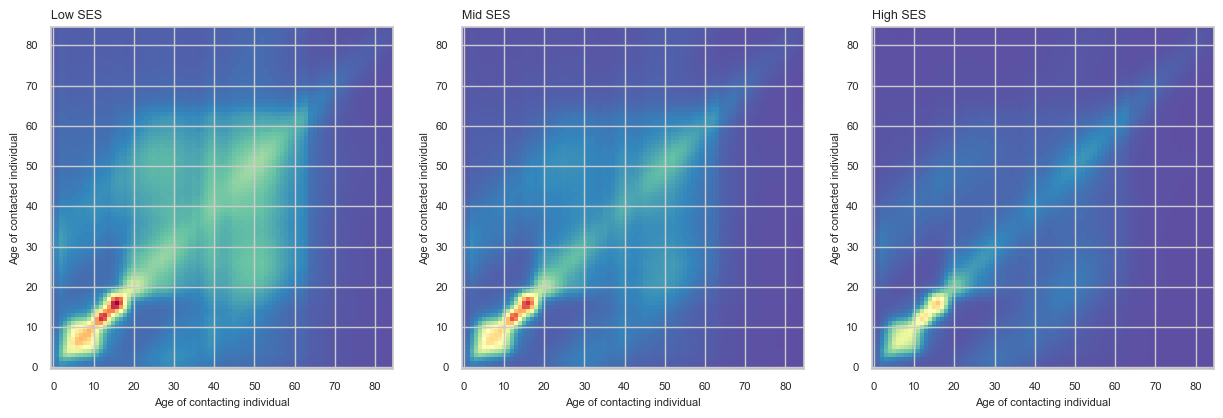

In [4]:
cint_eval, mcint_eval = data_eval

cint_low = cint_eval['ses']['low']
cint_mid = cint_eval['ses']['mid']
cint_high = cint_eval['ses']['high']

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.vstack((cint_low, cint_mid, cint_high)).min()
vmax = np.vstack((cint_low, cint_mid, cint_high)).max()

plot_contact_matrix(ax[0], cint_low, title='Low SES', vmin=vmin, vmax=vmax)
plot_contact_matrix(ax[1], cint_mid, title='Mid SES', vmin=vmin, vmax=vmax)
plot_contact_matrix(ax[2], cint_high, title='High SES', vmin=vmin, vmax=vmax)

plt.show()

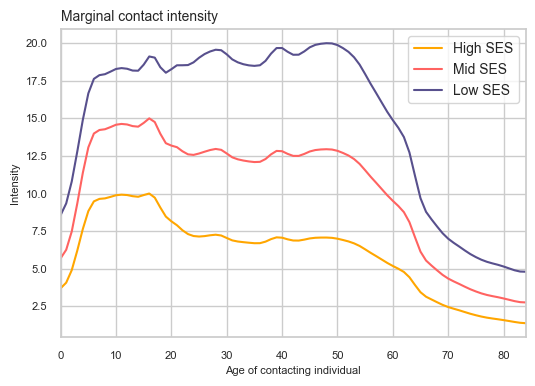

In [5]:
fig, ax = plt.subplots(figsize=(6,4))

mcint_low = mcint_eval['ses']['low']
mcint_mid = mcint_eval['ses']['mid']
mcint_high = mcint_eval['ses']['high']

plot_contact_marginal(ax, mcint_high, color='#ffa600', label='High SES')
plot_contact_marginal(ax, mcint_mid, color='#ff6361', label='Mid SES')
plot_contact_marginal(ax, mcint_low, color='#58508d', label='Low SES')

ax.set_xlim(0, 84)
ax.set_title('Marginal contact intensity', loc='left', fontsize=10)

ax.legend(loc='upper right', fontsize=10)
plt.show()

In [6]:
model = HiBRCfine(df_train, age_dist.P.values, age_dist_props)
model.set_hsgp_params(grid_type='diff-age')
model.print_model_shape()

              Trace Shapes:              
               Param Sites:              
              Sample Sites:              
              baseline dist         |    
                      value         |    
              gp_scale dist         |    
                      value         |    
           gp_lenscale dist         |    
                      value         |    
      hsgp_basis_coef plate     900 |    
                  beta dist     900 |    
                      value     900 |    
          ses/x_alpha plate       2 |    
ses/tpspline_intercept dist 2     1 |    
                      value 2     1 |    
           ses/x_beta plate       2 |    
     ses/tpspline_coef dist       2 | 841
                      value       2 | 841
                 data plate   21675 |    
              inv_disp dist   21675 |    
                      value   21675 |    
                   obs dist   21675 |    
                      value   21675 |    


In [7]:
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_value

init_values = {
  'baseline': -model.log_P.mean(),
  'hsgp_scale': 0.1,
  'hsgp_lengthscale': 1.0
}

prng_key = jax.random.PRNGKey(0)
guide = AutoNormal(model.model, init_loc_fn=init_to_value(values=init_values))
model.run_inference_svi(prng_key, guide)

100%|██████████| 5000/5000 [01:30<00:00, 55.40it/s, init loss: 251483.4219, avg. loss [4751-5000]: 33657.7493]


In [9]:
from cntmosaic.sim._eval import ModelEvaluatorSVI

evaluator = ModelEvaluatorSVI(model, data_eval)
post_cint = evaluator.summary_cint()
post_mcint = evaluator.summary_mcint()

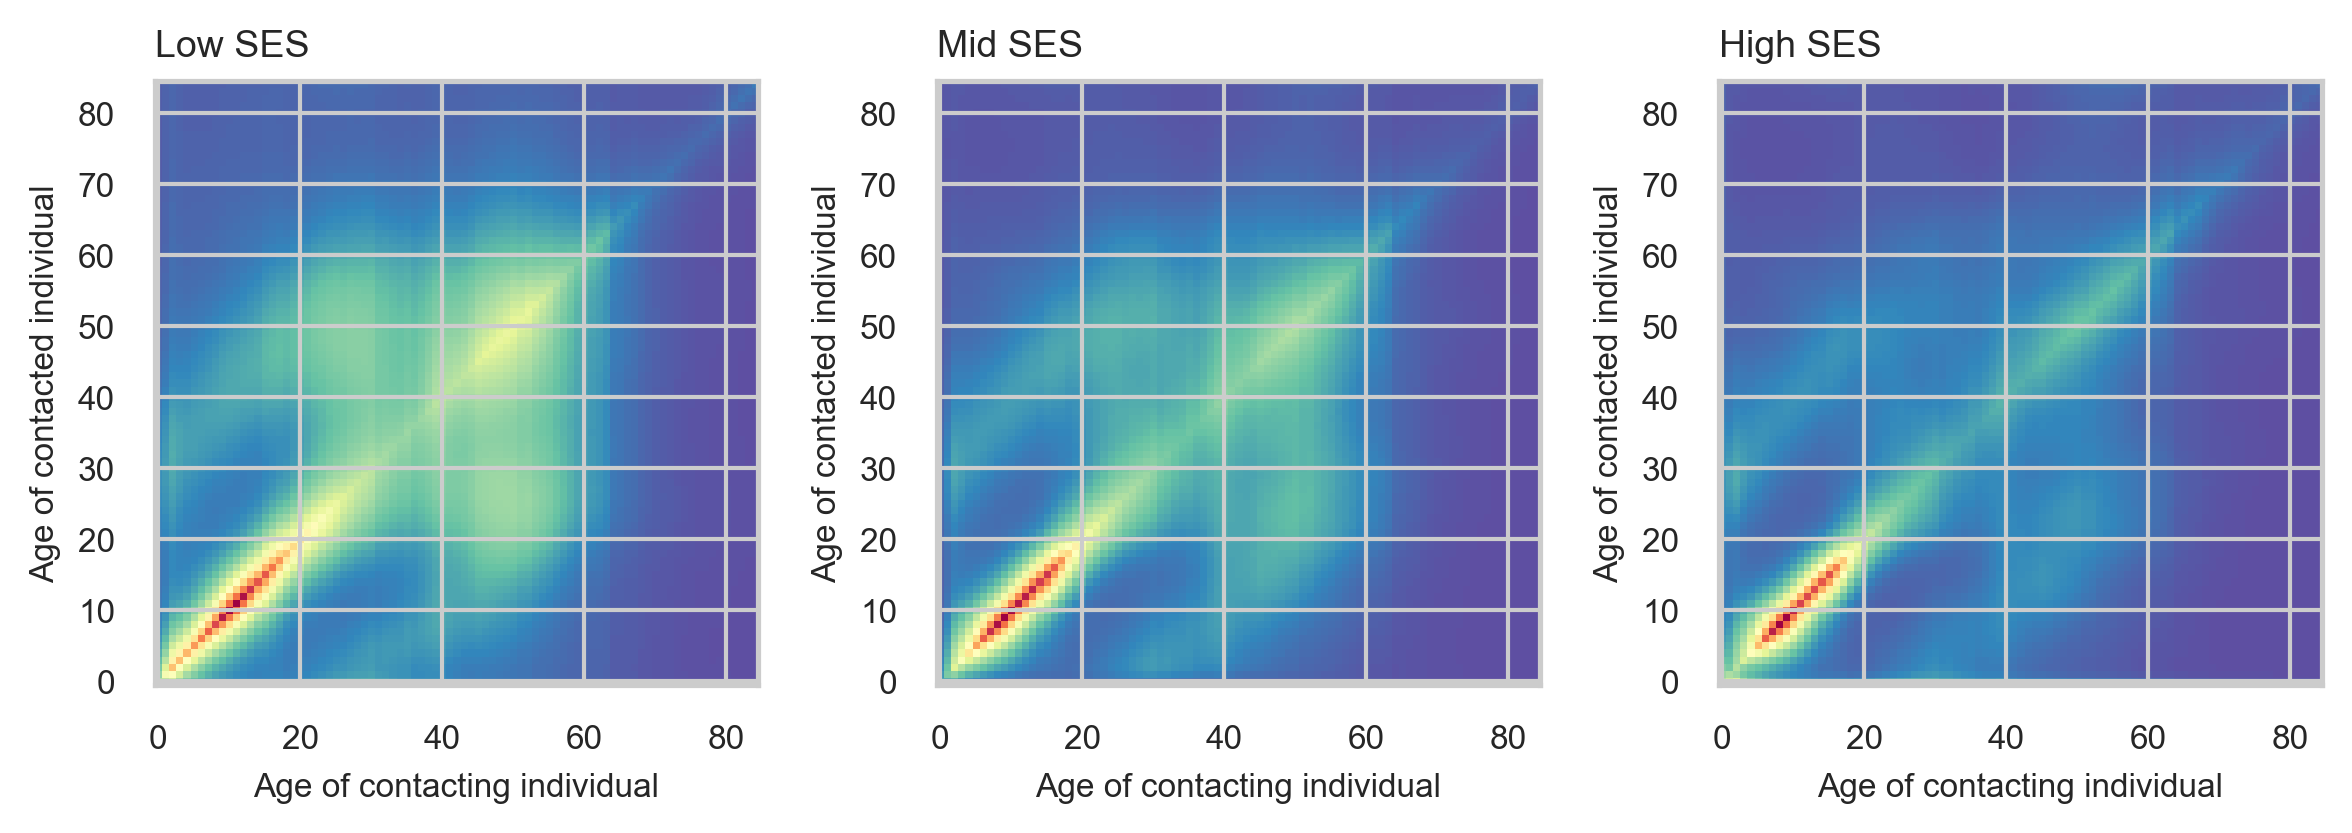

In [10]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 3), dpi=300)
gs = GridSpec(1, 3, width_ratios=[1, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

plot_contact_matrix(ax0, post_cint['ses']['low'][1,:,:], title='Low SES')
plot_contact_matrix(ax1, post_cint['ses']['mid'][1,:,:], title='Mid SES')
plot_contact_matrix(ax2, post_cint['ses']['high'][1,:,:], title='High SES')

gs.tight_layout(fig)
plt.show()

In [11]:
evaluator.evaluate_cint()

AttributeError: 'ModelEvaluatorSVI' object has no attribute 'summary_pred_cint'

(0.0, 84.0)

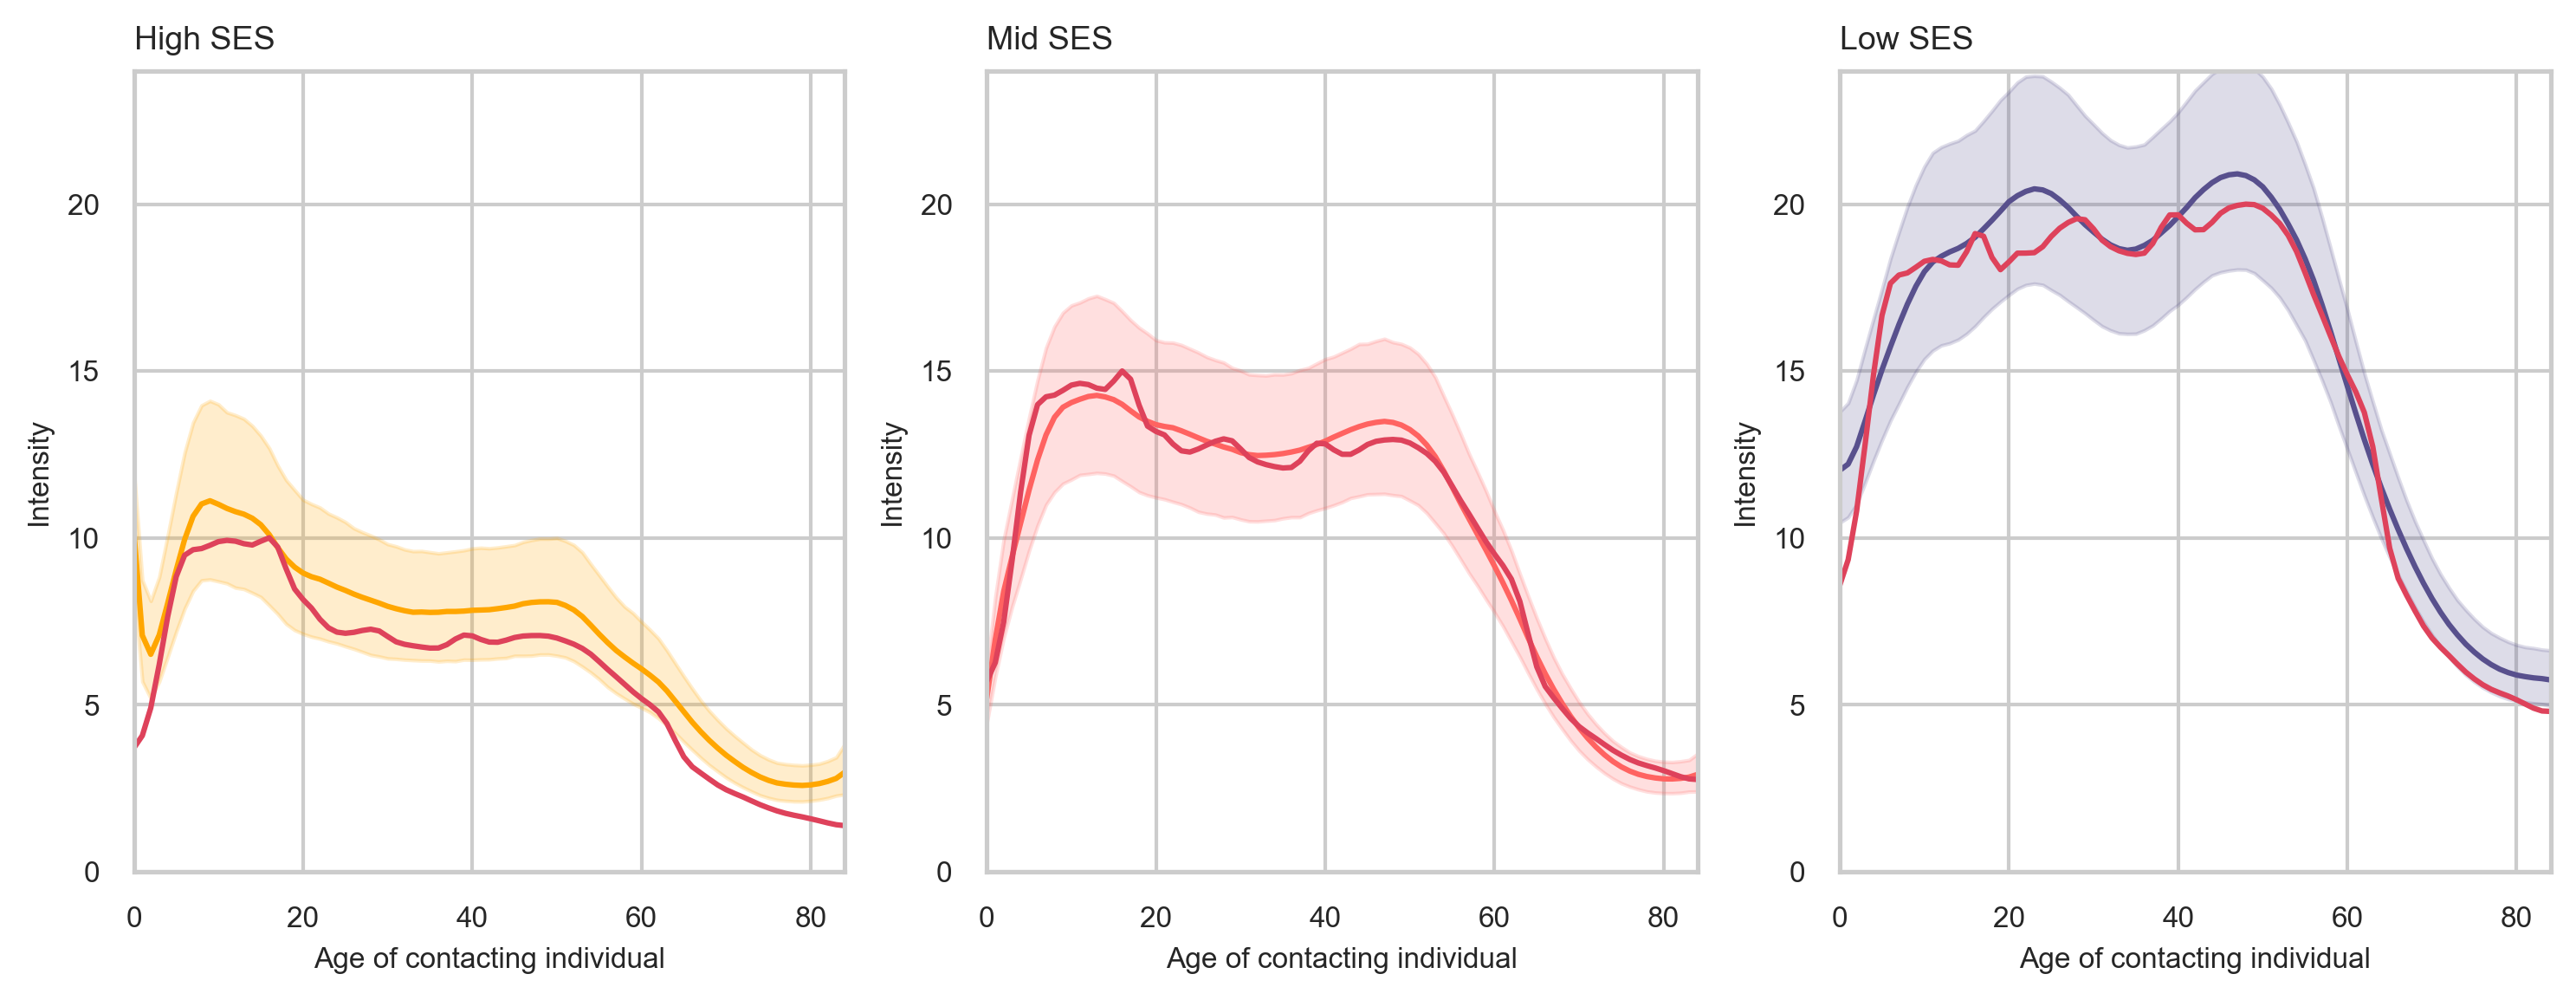

In [12]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize=(12,4), dpi=300)

plot_contact_marginal(ax[0],
                   post_mcint['ses']['high'][1],
                   post_mcint['ses']['high'][0],
                   post_mcint['ses']['high'][2],
                   color='#ffa600')
plot_contact_marginal(ax[0], mcint_eval['ses']['high'], color='#de425b', title='High SES')
ax[0].set_ylim(0, 24)
ax[0].set_xlim(0, 84)

plot_contact_marginal(ax[1],
                   post_mcint['ses']['mid'][1,:],
                   post_mcint['ses']['mid'][0,:],
                   post_mcint['ses']['mid'][2,:],
                   color='#ff6361')
plot_contact_marginal(ax[1], mcint_eval['ses']['mid'], color='#de425b', title='Mid SES')
ax[1].set_ylim(0, 24)
ax[1].set_xlim(0, 84)

plot_contact_marginal(ax[2],
                   post_mcint['ses']['low'][1,:],
                   post_mcint['ses']['low'][0,:],
                   post_mcint['ses']['low'][2,:],
                   color='#58508d')
plot_contact_marginal(ax[2], mcint_eval['ses']['low'], color='#de425b', title='Low SES')
ax[2].set_ylim(0, 24)
ax[2].set_xlim(0, 84)

In [13]:
evaluator.evaluate_mcint()

AttributeError: 'ModelEvaluatorSVI' object has no attribute 'summary_pred_mcint'